In [1]:
import numpy as np
import pandas as pd
import pyfolio as pf
import matplotlib.pyplot as plt

C:\Users\ckddn\anaconda3\Lib\site-packages\pyfolio\pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


In [2]:
#plot 한글 적용
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [3]:
RISKY_ASSETS = ['AAPL', 'IBM', 'MSFT']
START_DATE = '2017-01-01'
END_DATE = '2018-12-31'
n_assets = len(RISKY_ASSETS)

In [4]:
def getAssetsStock(tickers, startDate, endDate):
    FILE_PATH = "../Data-collection/dailyStock"
    dic = {}
    
    for ticker in tickers:
        ticker_df = pd.read_csv(f"{FILE_PATH}/{ticker}.csv", encoding="utf-8")
        ticker_df['Date'] = pd.to_datetime(ticker_df['Date'])
        ticker_df = ticker_df.set_index('Date')
        ticker_df = ticker_df.loc[startDate:endDate]
        
        dic[ticker] = ticker_df['adj_close']
    
    returns_df = pd.DataFrame(dic)
    
    return returns_df

### 데이터 불러오기(2017~2018년도)

In [5]:
price_df = getAssetsStock(RISKY_ASSETS, START_DATE, END_DATE)
returns = price_df.pct_change().dropna()   #개별수익률 산정

portfolio_weights = n_assets * [1 / n_assets]  #가중치 정의

<Axes: title={'center': '주가정보'}, xlabel='Date'>

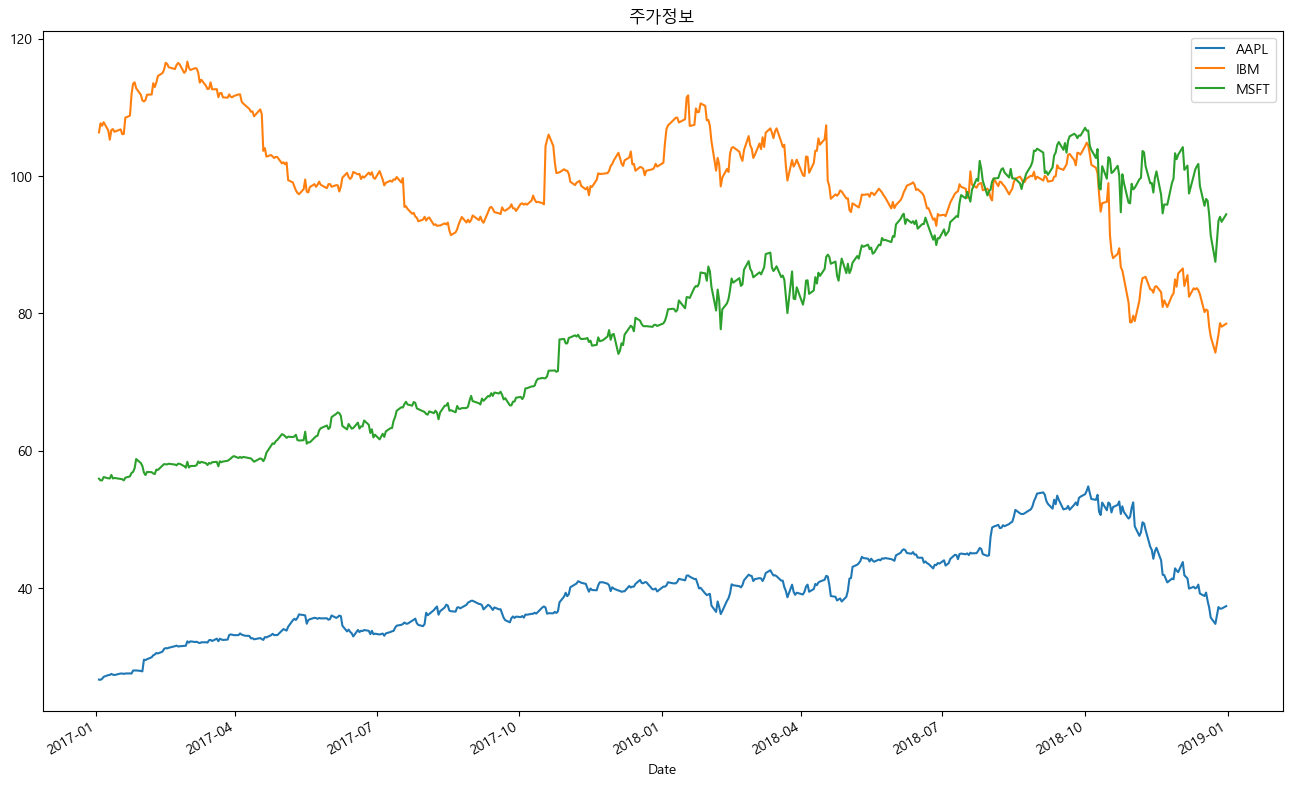

In [6]:
price_df.plot(title="주가정보", figsize=(16,10))

In [7]:
portfolio_returns = pd.Series(np.dot(portfolio_weights, returns.T), index=returns.index)

C:\Users\ckddn\anaconda3\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10.746%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2017-01-04
End date,2018-12-31
Total months,23
,Backtest
Annual return,10.746%
Cumulative returns,22.497%
Annual volatility,18.125%
Sharpe ratio,0.65
Calmar ratio,0.39
Stability,0.80
Max drawdown,-27.9%


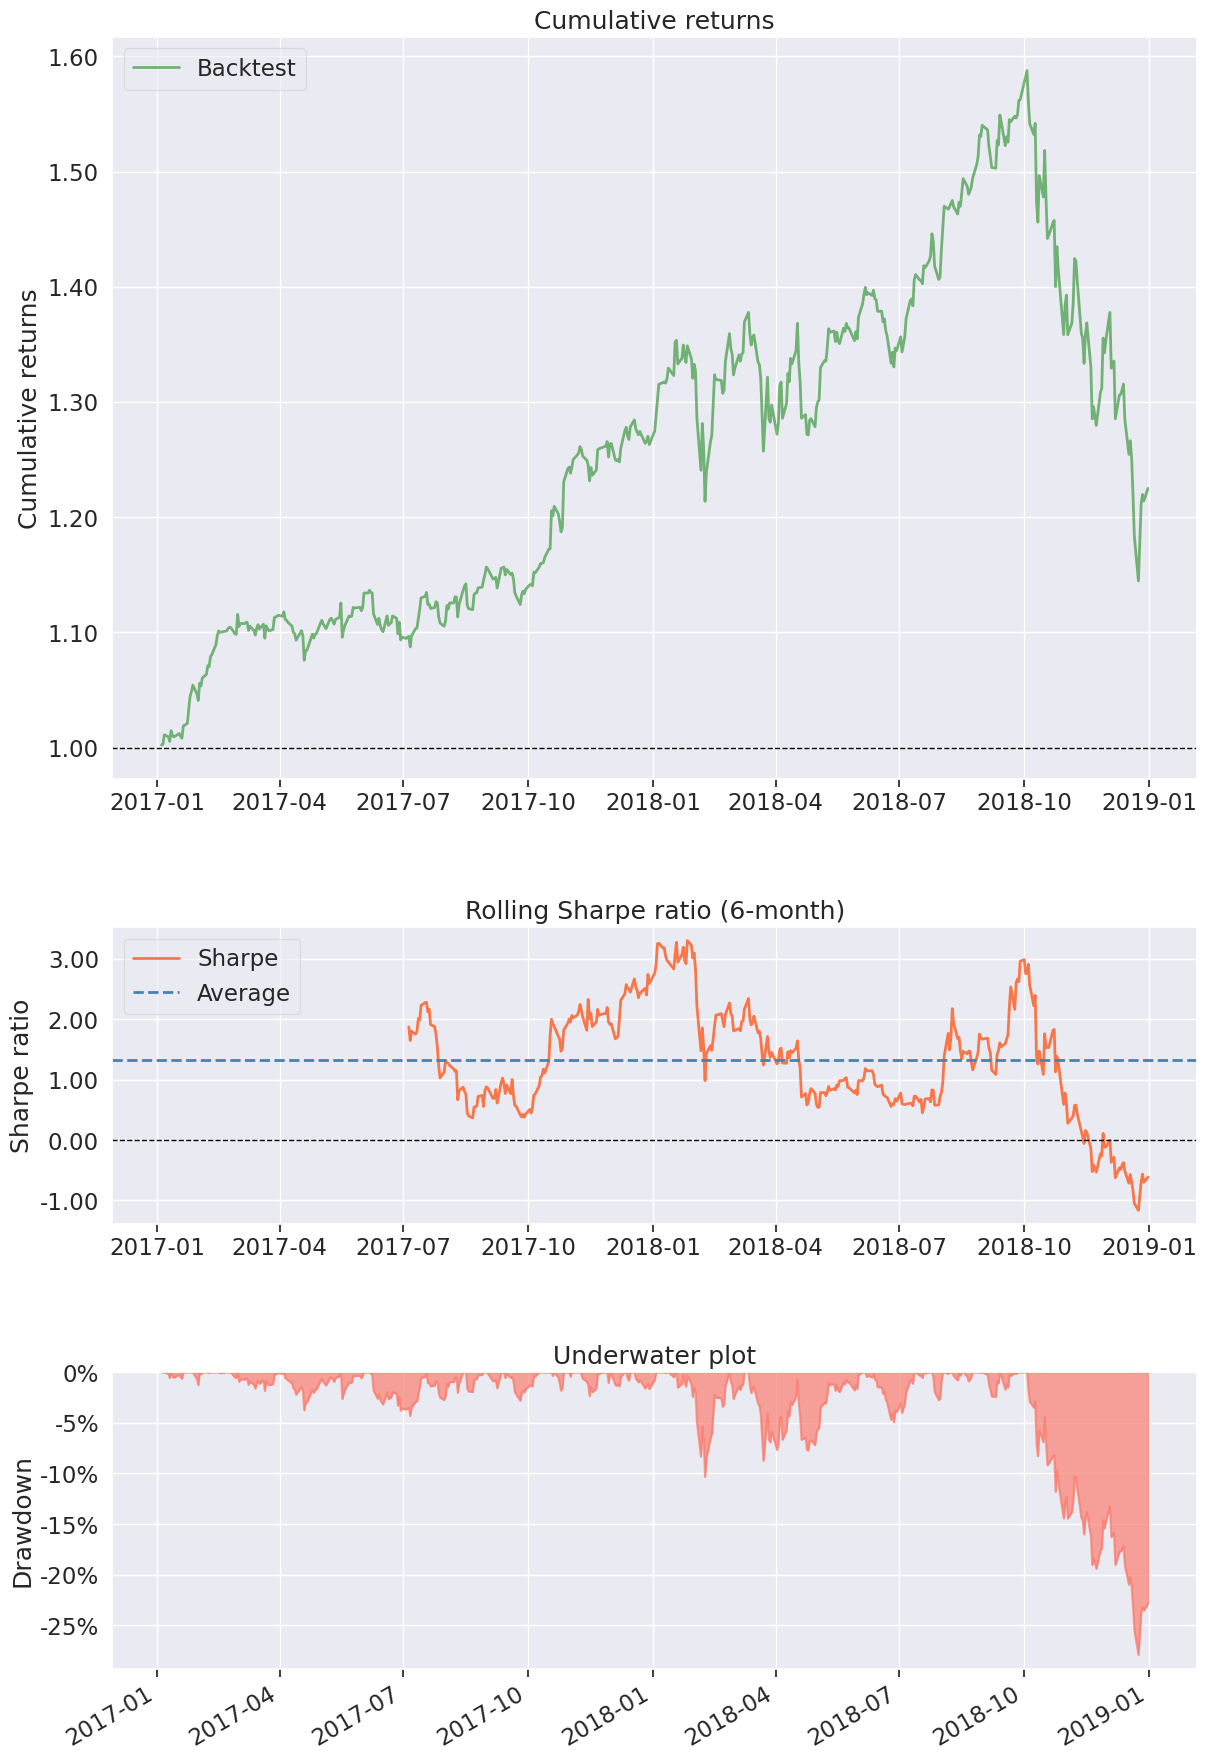

In [8]:
pf.create_simple_tear_sheet(portfolio_returns)

C:\Users\ckddn\anaconda3\Lib\site-packages\pyfolio\plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '10.746%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2017-01-04
End date,2018-12-31
Total months,23
,Backtest
Annual return,10.746%
Cumulative returns,22.497%
Annual volatility,18.125%
Sharpe ratio,0.65
Calmar ratio,0.39
Stability,0.80
Max drawdown,-27.9%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,27.90,2018-10-03,2018-12-24,NaT,NaN
1,10.32,2018-01-18,2018-02-08,2018-02-26,28
2,8.74,2018-03-12,2018-03-23,2018-06-04,61
3,4.94,2018-06-06,2018-06-27,2018-07-12,27
4,4.33,2017-06-06,2017-07-06,2017-08-14,50


C:\Users\ckddn\anaconda3\Lib\site-packages\pyfolio\plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])


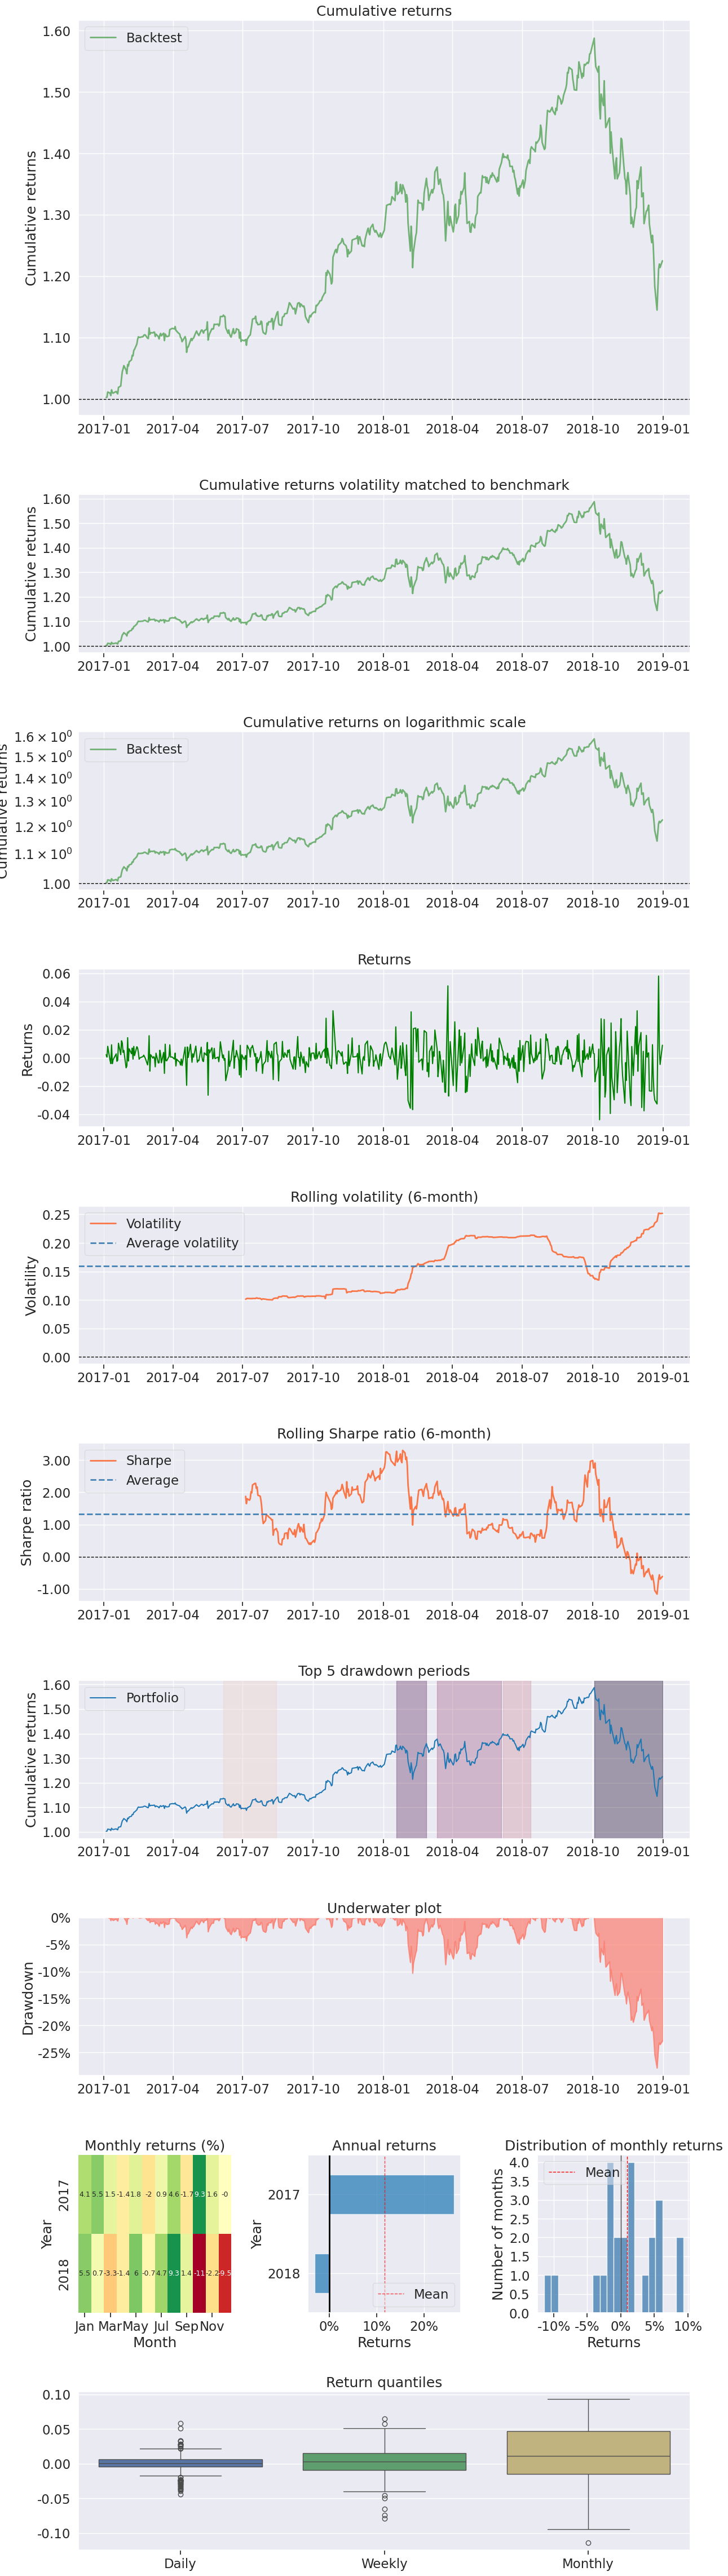

In [9]:
#수익률, 샤프 비율, 최대 낙폭 시각화
pf.create_returns_tear_sheet(portfolio_returns)